In [ ]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
# load data

df = pd.read_csv("/content/SVMtrain.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,Male,22.0,1,0,7.2500,3
1,2,1,1,female,38.0,1,0,71.2833,1
2,3,1,3,female,26.0,0,0,7.9250,3
3,4,1,1,female,35.0,1,0,53.1000,3
4,5,0,3,Male,35.0,0,0,8.0500,3


In [ ]:
df.shape

(889, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    object 
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Fare         889 non-null    float64
 8   Embarked     889 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 62.6+ KB


In [ ]:
# statastical summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,35.686355,0.524184,0.382452,32.096681,2.535433
std,256.998173,0.486260,0.834700,17.756733,1.103705,0.806761,49.697504,0.792088
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800,2.000000
50%,446.000000,0.000000,3.000000,32.000000,0.000000,0.000000,14.454200,3.000000
75%,668.000000,1.000000,3.000000,54.000000,1.000000,0.000000,31.000000,3.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,3.000000


In [ ]:
# missing values

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
# checking outliers

num_cols = df.select_dtypes(include=np.number).columns

outlier_count = {}

for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  outlier_count[col] = outliers.shape[0]

print(outlier_count)


{'PassengerId': 0, 'Survived': 0, 'Pclass': 0, 'Age': 0, 'SibSp': 46, 'Parch': 213, 'Fare': 114, 'Embarked': 0}


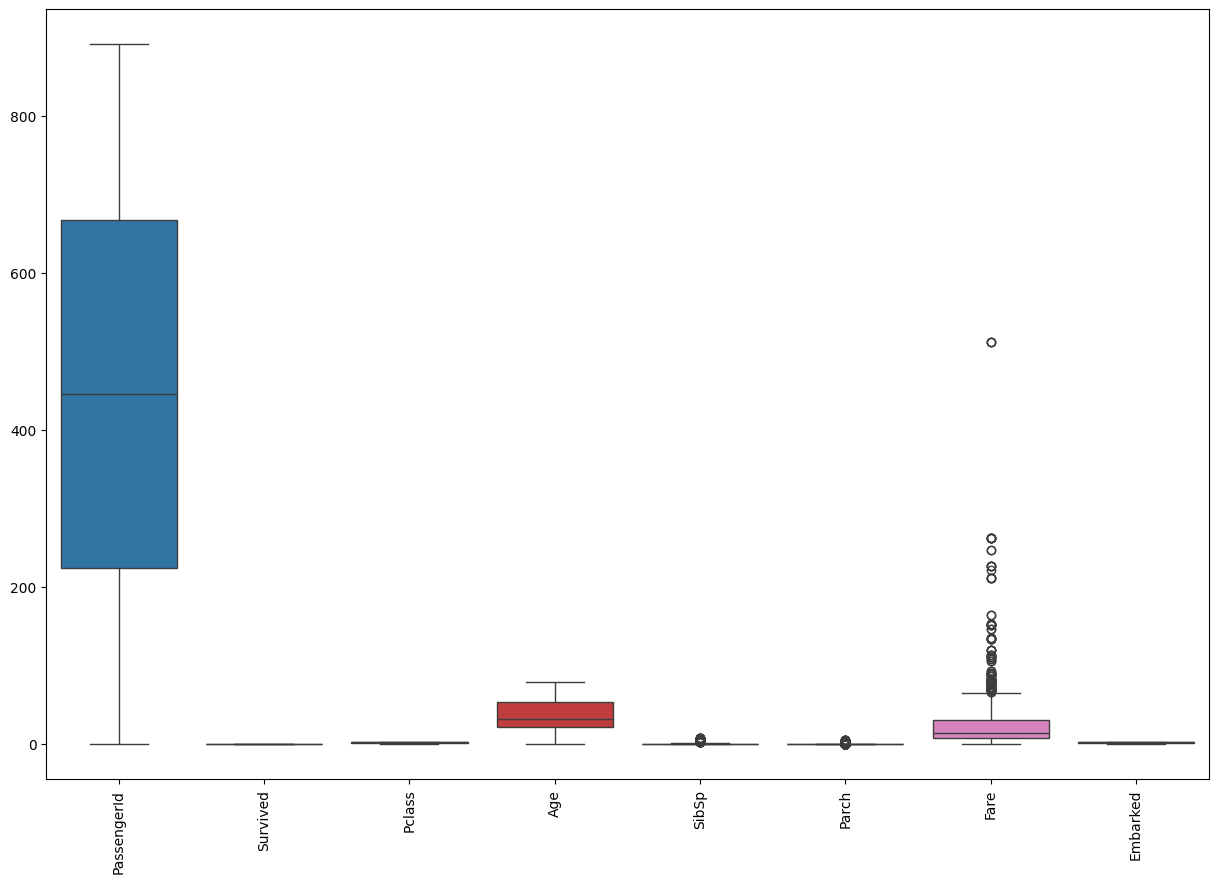

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()

In [ ]:
# target counts

df['Survived'].value_counts()


,count
Survived,
0,549
1,340


<Axes: xlabel='Sex', ylabel='count'>

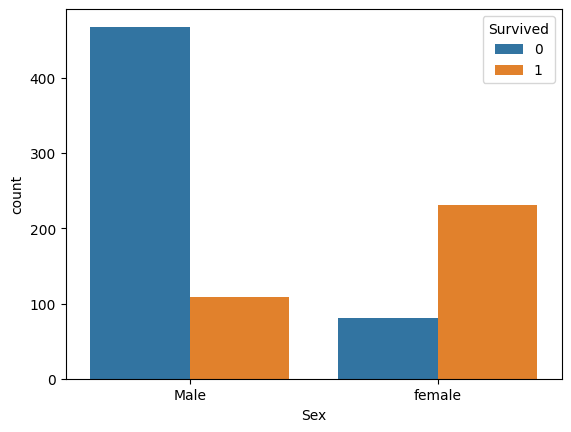

In [ ]:
#Feature vs target

sns.countplot(x='Sex', hue='Survived', data=df)



<Axes: xlabel='Pclass', ylabel='count'>

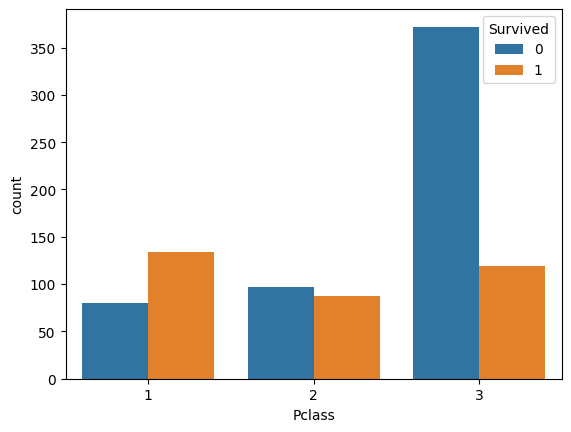

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=df)

In [ ]:
# Checking skewness

df.skew(numeric_only=True)


,0
PassengerId,0.000000
Survived,0.484568
Pclass,-0.636998
Age,0.104457
SibSp,3.691058
Parch,2.745160
Fare,4.801440
Embarked,-1.261367


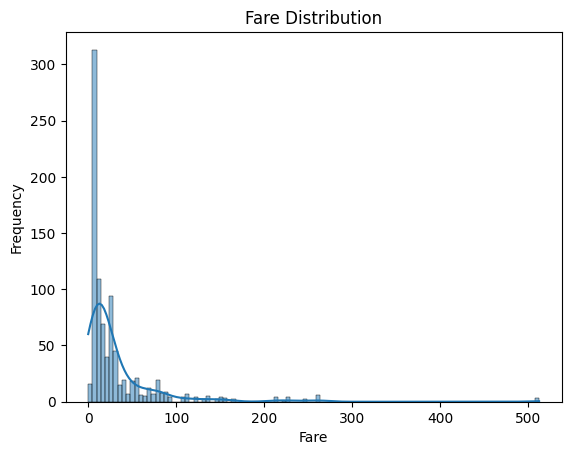

In [ ]:
#visualization of skewness
sns.histplot(df['Fare'], kde= True)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()




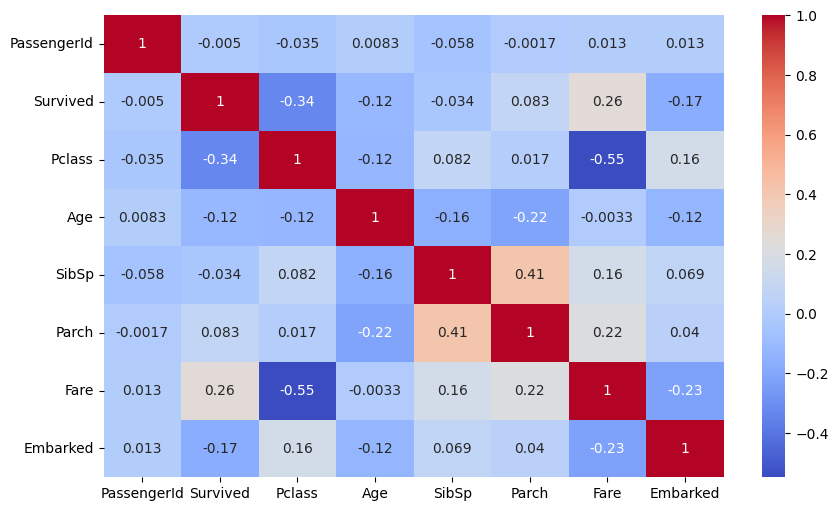

In [ ]:
# correlation

# Heatmap
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
#Feature engineering

#transform skewness

df['Fare']=np.log1p(df['Fare'])
print("after:", df['Fare'].skew())

after: 0.40010918935230094


In [ ]:
# encoding

from sklearn.preprocessing import LabelEncoder,OneHotEncoder
df.drop('PassengerId', axis = 1 , inplace = True)

#Encode sex
df['Sex'] = df['Sex'].map({'Male':0, 'female':1})

#one hot encode Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [ ]:
# Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_2,Embarked_3
0,0,3,0,-0.771204,1,0,-0.877591,False,True
1,1,1,1,0.130370,1,0,1.366380,False,False
2,1,3,1,-0.545810,0,0,-0.796281,False,True
3,1,1,1,-0.038675,1,0,1.066796,False,True
4,0,3,0,-0.038675,0,0,-0.781901,False,True
